# Seminar 3: Collaborative Filtering Algorithms

## Goals

In this seminar we will:
1. Implement **Item-to-Item kNN** collaborative filtering from scratch
2. Implement **SLIM** (Sparse Linear Methods) from scratch
3. Use **User-to-User kNN** from the `implicit` library
4. Use **EASE** (Embarrassingly Shallow Autoencoders) from the `RecTools` library
5. Compare all four algorithms using **ranking metrics** on the MovieLens 100k dataset

## 0. Setup

In [2]:
# !pip install numba implicit rectools

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm

plt.style.use("ggplot")

## 1. Dataset: MovieLens 100k

We use [MovieLens 100k](https://grouplens.org/datasets/movielens/100k/) — a classic benchmark for collaborative filtering:

- **100,000 ratings** (1--5 scale)
- **943 users** and **1,682 movies**
- Each user has rated at least 20 movies
- Timestamps available for temporal train/test splitting

In [25]:
import os, zipfile, urllib.request

DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
DATA_DIR = "ml-100k"

if not os.path.exists(DATA_DIR):
    print("Downloading MovieLens 100k...")
    urllib.request.urlretrieve(DATA_URL, "ml-100k.zip")
    with zipfile.ZipFile("ml-100k.zip", "r") as z:
        z.extractall(".")
    print("Done.")

ratings = pd.read_csv(
    os.path.join(DATA_DIR, "u.data"),
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
)

movies = pd.read_csv(
    os.path.join(DATA_DIR, "u.item"),
    sep="|",
    encoding="latin-1",
    usecols=[0, 1],
    names=["item_id", "title"],
)

print(f"Ratings: {len(ratings):,}")
print(f"Users:   {ratings['user_id'].nunique():,}")
print(f"Items:   {ratings['item_id'].nunique():,}")
ratings.head()

Ratings: 100,000
Users:   943
Items:   1,682


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 2. Exploratory Data Analysis

In [26]:
n_users = ratings["user_id"].nunique()
n_items = ratings["item_id"].nunique()
sparsity = 1 - len(ratings) / (n_users * n_items)

print(f"Number of ratings:    {len(ratings):,}")
print(f"Unique users:         {n_users:,}")
print(f"Unique items:         {n_items:,}")
print(f"Rating range:         {ratings['rating'].min()} - {ratings['rating'].max()}")
print(f"Sparsity:             {sparsity:.4f} ({sparsity*100:.2f}%)")

Number of ratings:    100,000
Unique users:         943
Unique items:         1,682
Rating range:         1 - 5
Sparsity:             0.9370 (93.70%)


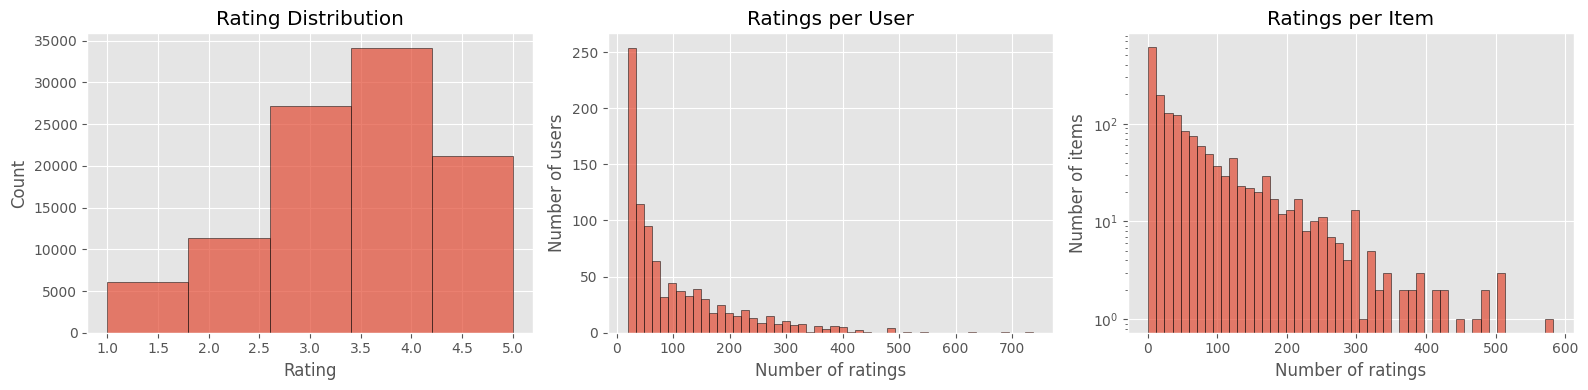

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(ratings["rating"], bins=5, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].set_title("Rating Distribution")

user_counts = ratings.groupby("user_id").size()
axes[1].hist(user_counts, bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Number of users")
axes[1].set_title("Ratings per User")

item_counts = ratings.groupby("item_id").size()
axes[2].hist(item_counts, bins=50, edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Number of ratings")
axes[2].set_ylabel("Number of items")
axes[2].set_title("Ratings per Item")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

## 3. Data Preparation

### Train/Test Split: Leave-Last-Out

For each user, the **last interaction** (by timestamp) goes to the **test set**,
all previous interactions form the **training set**.
This mimics a realistic scenario: we train on historical data and evaluate
on the most recent behavior.

We also convert ratings into an **implicit feedback** signal (rating >= 4 is positive)
for ranking evaluation.

In [28]:
ratings = ratings.sort_values(["user_id", "timestamp"])

ratings["rank"] = ratings.groupby("user_id")["timestamp"].rank(
    method="first", ascending=False
)

test = ratings[ratings["rank"] == 1].drop(columns="rank")
train = ratings[ratings["rank"] > 1].drop(columns="rank")

print(f"Train set: {len(train):,} ratings")
print(f"Test set:  {len(test):,} ratings (1 per user)")
print(f"Users in test: {test['user_id'].nunique():,}")

Train set: 99,057 ratings
Test set:  943 ratings (1 per user)
Users in test: 943


In [29]:
train_user_items = (
    train.groupby("user_id")["item_id"].apply(set).to_dict()
)

RELEVANCE_THRESHOLD = 4
ground_truth = (
    test[test["rating"] >= RELEVANCE_THRESHOLD]
    .groupby("user_id")["item_id"]
    .apply(set)
    .to_dict()
)

all_items = set(ratings["item_id"].unique())
K = 10

print(f"Users with relevant test items (rating >= {RELEVANCE_THRESHOLD}): {len(ground_truth):,}")
print(f"Catalog size: {len(all_items):,}")
print(f"Evaluation cutoff K = {K}")

Users with relevant test items (rating >= 4): 475
Catalog size: 1,682
Evaluation cutoff K = 10


### Build User-Item Matrix

We create a sparse user-item matrix from the training data. Users and items
are re-indexed to 0-based contiguous indices for efficient matrix operations.

In [ ]:
1000 * 1700 = 1 700 000

In [43]:
user_ids_all = sorted(ratings["user_id"].unique())
item_ids_all = sorted(ratings["item_id"].unique())

user2idx = {uid: i for i, uid in enumerate(user_ids_all)}
idx2user = {i: uid for uid, i in user2idx.items()}
item2idx = {iid: i for i, iid in enumerate(item_ids_all)}
idx2item = {i: iid for iid, i in item2idx.items()}

n_users_total = len(user_ids_all)
n_items_total = len(item_ids_all)

row = train["user_id"].map(user2idx).values
col = train["item_id"].map(item2idx).values
data = train["rating"].values.astype(np.float32)

R_train = sparse.csr_matrix((data, (row, col)), shape=(n_users_total, n_items_total))

R_train_binary = (R_train > 0).astype(np.float32)

print(f"R_train shape: {R_train.shape}")
print(f"Non-zero entries: {R_train.nnz:,}")
print(f"Sparsity: {1 - R_train.nnz / (R_train.shape[0] * R_train.shape[1]):.4f}")

R_train shape: (943, 1682)
Non-zero entries: 99,057
Sparsity: 0.9375


## 4. Evaluation Metrics

We implement standard ranking metrics from scratch. All metrics work with:
- `recommendations: dict[user_id -> list[item_id]]` — ordered list of K recommended items
- `ground_truth: dict[user_id -> set[item_id]]` — set of relevant items per user

> With leave-last-out, each user has at most 1 relevant item. HitRate = Recall and MAP = MRR in this case.

In [44]:
def hit_rate_at_k(recommendations, ground_truth, k):
    hits, total = 0, 0
    for uid, rec_list in recommendations.items():
        if uid not in ground_truth:
            continue
        if set(rec_list[:k]) & ground_truth[uid]:
            hits += 1
        total += 1
    return hits / total if total > 0 else 0.0


def precision_at_k(recommendations, ground_truth, k):
    precisions = []
    for uid, rec_list in recommendations.items():
        if uid not in ground_truth:
            continue
        relevant = len(set(rec_list[:k]) & ground_truth[uid])
        precisions.append(relevant / k)
    return np.mean(precisions) if precisions else 0.0


def recall_at_k(recommendations, ground_truth, k):
    recalls = []
    for uid, rec_list in recommendations.items():
        if uid not in ground_truth:
            continue
        relevant_found = len(set(rec_list[:k]) & ground_truth[uid])
        total_relevant = len(ground_truth[uid])
        recalls.append(relevant_found / total_relevant if total_relevant > 0 else 0.0)
    return np.mean(recalls) if recalls else 0.0


def map_at_k(recommendations, ground_truth, k):
    aps = []
    for uid, rec_list in recommendations.items():
        if uid not in ground_truth:
            continue
        hits = 0
        sum_prec = 0.0
        for i, item in enumerate(rec_list[:k]):
            if item in ground_truth[uid]:
                hits += 1
                sum_prec += hits / (i + 1)
        aps.append(sum_prec / min(len(ground_truth[uid]), k) if ground_truth[uid] else 0.0)
    return np.mean(aps) if aps else 0.0


def ndcg_at_k(recommendations, ground_truth, k):
    ndcgs = []
    for uid, rec_list in recommendations.items():
        if uid not in ground_truth:
            continue
        dcg = sum(
            1.0 / np.log2(i + 2)
            for i, item in enumerate(rec_list[:k])
            if item in ground_truth[uid]
        )
        ideal_hits = min(len(ground_truth[uid]), k)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)
    return np.mean(ndcgs) if ndcgs else 0.0


def evaluate_model(recommendations, ground_truth, k):
    return {
        "Precision@K": precision_at_k(recommendations, ground_truth, k),
        "Recall@K": recall_at_k(recommendations, ground_truth, k),
        "MAP@K": map_at_k(recommendations, ground_truth, k),
        "NDCG@K": ndcg_at_k(recommendations, ground_truth, k),
        "HitRate@K": hit_rate_at_k(recommendations, ground_truth, k),
    }

---

## 5. Item-to-Item kNN

Item-based collaborative filtering is one of the foundational recommendation algorithms
(Sarwar et al., 2001). The core idea: **similar items tend to be liked by the same users**.

#### Step 1: Item Similarity

We compute pairwise similarity between items using **cosine similarity** on the
columns of the user-item matrix $R$. Each item $i$ is represented by a vector
$\mathbf{r}_i \in \mathbb{R}^{|U|}$ of all user ratings for that item:

$$\text{sim}(i, j) = \cos(\mathbf{r}_i, \mathbf{r}_j) = \frac{\mathbf{r}_i \cdot \mathbf{r}_j}{\|\mathbf{r}_i\| \cdot \|\mathbf{r}_j\|}$$

#### Step 2: Neighborhood

For each item $i$, we keep only the $k$ most similar items $N_k(i)$. This reduces
noise and makes scoring faster.

#### Step 3: Score Prediction

For a user $u$ and a candidate item $i$ (not yet rated by $u$), the predicted
score is a **weighted average** of $u$'s ratings on items similar to $i$:

$$\hat{r}_{u,i} = \frac{\sum_{j \in N_k(i) \cap I_u} \text{sim}(i,j) \cdot r_{u,j}}{\sum_{j \in N_k(i) \cap I_u} |\text{sim}(i,j)|}$$

where $I_u$ is the set of items rated by user $u$.

#### Step 4: Recommendation

For each user, we score all candidate items (those not in $I_u$), sort by
predicted score, and return the top-$N$.

In [45]:
class ItemKNN:
    def __init__(self, k_neighbors=50):
        self.k = k_neighbors
        self.sim_matrix = None
        self.R = None

    def fit(self, R):
        """Compute item-item cosine similarity and keep top-k neighbors."""
        self.R = R.copy()
        # cosine_similarity works on rows, so transpose to get items as rows
        item_sim = cosine_similarity(R.T, dense_output=False)
        # zero out the diagonal (item is not its own neighbor)
        item_sim.setdiag(0)
        item_sim.eliminate_zeros()
        item_sim = item_sim.toarray()

        # keep only top-k neighbors per item
        for i in range(item_sim.shape[0]):
            row = item_sim[i]
            if self.k < len(row):
                threshold = np.partition(row, -self.k)[-self.k]
                row[row < threshold] = 0.0
        self.sim_matrix = sparse.csr_matrix(item_sim)
        return self

    def recommend(self, user_ids, train_user_items, idx2item, user2idx, n=10):
        """Generate top-n recommendations for each user."""
        scores = self.R @ self.sim_matrix
        recommendations = {}

        for uid in tqdm(user_ids, desc="i2i kNN recommend"):
            uidx = user2idx[uid]
            user_scores = np.asarray(scores[uidx].todense()).flatten()

            seen_idx = [item2idx[iid] for iid in train_user_items.get(uid, set()) if iid in item2idx]
            user_scores[seen_idx] = -np.inf

            top_idx = np.argsort(user_scores)[::-1][:n]
            recommendations[uid] = [idx2item[i] for i in top_idx]

        return recommendations

In [47]:
i2i_model = ItemKNN(k_neighbors=50)
i2i_model.fit(R_train)

eval_users = list(ground_truth.keys())
recs_i2i = i2i_model.recommend(eval_users, train_user_items, idx2item, user2idx, n=K)

results_i2i = evaluate_model(recs_i2i, ground_truth, K)
print("Item-to-Item kNN results:")
for metric, value in results_i2i.items():
    print(f"  {metric}: {value:.4f}")

i2i kNN recommend:   0%|          | 0/475 [00:00<?, ?it/s]

Item-to-Item kNN results:
  Precision@K: 0.0158
  Recall@K: 0.1579
  MAP@K: 0.0542
  NDCG@K: 0.0783
  HitRate@K: 0.1579


---

## 6. SLIM

**SLIM** (Sparse Linear Methods, Ning & Karypis 2011) learns a **sparse item-item
weight matrix** $W \in \mathbb{R}^{|I| \times |I|}$ such that the user-item interaction
matrix $R$ can be approximated by $R \cdot W$.

#### Objective

$$\min_{W} \; \frac{1}{2}\|R - RW\|_F^2 + \frac{\lambda_2}{2}\|W\|_F^2 + \lambda_1\|W\|_1$$

subject to:
- $\text{diag}(W) = 0$ (an item should not predict itself)
- $W \geq 0$ (optional, encourages positive associations)

#### Column-wise Decomposition

The optimization **decomposes** into independent problems per item. For each
item $j$, we solve:

$$\min_{\mathbf{w}_j} \; \frac{1}{2}\|\mathbf{r}_j - R \mathbf{w}_j\|_2^2 + \frac{\lambda_2}{2}\|\mathbf{w}_j\|_2^2 + \lambda_1\|\mathbf{w}_j\|_1$$

with $w_{jj} = 0$.

#### Coordinate Descent Solution

We precompute the **Gram matrix** $G = R^\top R$ once. Then for each column $j$,
the update for coordinate $i$ uses the partial residual correlation:

$$\rho_i = G_{ij} - \sum_{k \neq i} G_{ik} \, w_{kj}$$

The coordinate update with soft-thresholding and non-negativity:

$$w_{ij} \leftarrow \frac{\max(0, \; \rho_i - \lambda_1)}{G_{ii} + \lambda_2}$$

This is repeated for all $i \neq j$ until convergence. The Gram matrix trick
avoids recomputing $R^\top R$ at every step, making the algorithm efficient.

#### Prediction

$$\hat{R} = R \cdot W$$

The learned weight $w_{ij}$ captures how much item $i$ contributes to
predicting interactions with item $j$. Sparsity ($\ell_1$ penalty) ensures
that only the most informative item relationships are kept.

In [48]:
import numba


@numba.njit
def _slim_cd_column(G, diag_G, j, l1_reg, l2_reg, n_iter):
    """Coordinate descent for one column of W (numba-accelerated).

    Uses the Gram matrix trick with incremental Gw updates:
    only recomputes the dot product when a weight actually changes.
    """
    n = len(diag_G)
    w = np.zeros(n)
    Gw = np.zeros(n)  # maintains G @ w incrementally

    for _ in range(n_iter):
        max_change = 0.0
        for i in range(n):
            if i == j or diag_G[i] < 1e-10:
                continue

            rho = G[i, j] - Gw[i] + diag_G[i] * w[i]
            old_wi = w[i]
            w[i] = max(0.0, rho - l1_reg) / (diag_G[i] + l2_reg)

            delta = w[i] - old_wi
            if abs(delta) > 1e-10:
                for k in range(n):
                    Gw[k] += delta * G[k, i]
                if abs(delta) > max_change:
                    max_change = abs(delta)

        if max_change < 1e-6:
            break

    return w


class SLIM:
    def __init__(self, l1_reg=1.0, l2_reg=0.5, n_iterations=30):
        self.l1_reg = l1_reg
        self.l2_reg = l2_reg
        self.n_iterations = n_iterations
        self.W = None
        self.R = None

    def fit(self, R):
        """Learn sparse weight matrix W via coordinate descent on the Gram matrix."""
        self.R = R.copy()
        n_items = R.shape[1]

        G = (R.T @ R).toarray().astype(np.float64)
        diag_G = np.diag(G).copy()

        W = np.zeros((n_items, n_items), dtype=np.float64)

        for j in tqdm(range(n_items), desc="SLIM fitting"):
            if diag_G[j] == 0:
                continue
            W[:, j] = _slim_cd_column(
                G, diag_G, j, self.l1_reg, self.l2_reg, self.n_iterations
            )

        self.W = sparse.csr_matrix(W)
        nnz = self.W.nnz
        total = n_items * n_items
        print(f"W sparsity: {1 - nnz / total:.4f} ({nnz:,} non-zero of {total:,})")
        return self

    def recommend(self, user_ids, train_user_items, idx2item, user2idx, n=10):
        """Generate top-n recommendations for each user."""
        scores = self.R @ self.W
        if sparse.issparse(scores):
            scores = scores.toarray()

        recommendations = {}
        for uid in tqdm(user_ids, desc="SLIM recommend"):
            uidx = user2idx[uid]
            user_scores = scores[uidx].copy()

            seen_idx = [item2idx[iid] for iid in train_user_items.get(uid, set()) if iid in item2idx]
            user_scores[seen_idx] = -np.inf

            top_idx = np.argsort(user_scores)[::-1][:n]
            recommendations[uid] = [idx2item[i] for i in top_idx]

        return recommendations

In [49]:
slim_model = SLIM(l1_reg=1.0, l2_reg=0.5, n_iterations=30)
slim_model.fit(R_train)

recs_slim = slim_model.recommend(eval_users, train_user_items, idx2item, user2idx, n=K)

results_slim = evaluate_model(recs_slim, ground_truth, K)
print("SLIM results:")
for metric, value in results_slim.items():
    print(f"  {metric}: {value:.4f}")

SLIM fitting:   0%|          | 0/1682 [00:00<?, ?it/s]

W sparsity: 0.9633 (103,835 non-zero of 2,829,124)


SLIM recommend:   0%|          | 0/475 [00:00<?, ?it/s]

SLIM results:
  Precision@K: 0.0177
  Recall@K: 0.1768
  MAP@K: 0.0822
  NDCG@K: 0.1042
  HitRate@K: 0.1768


---

## 7. User-to-User kNN

User-based collaborative filtering finds users **similar to the target user**
and aggregates their opinions to make predictions (Resnick et al., 1994).

#### Step 1: User Similarity

Similarity between users $u$ and $v$ is computed using **cosine similarity**
on the rows of the user-item matrix $R$. Each user $u$ is represented by
a vector $\mathbf{r}_u \in \mathbb{R}^{|I|}$ of their item ratings:

$$\text{sim}(u, v) = \cos(\mathbf{r}_u, \mathbf{r}_v) = \frac{\mathbf{r}_u \cdot \mathbf{r}_v}{\|\mathbf{r}_u\| \cdot \|\mathbf{r}_v\|}$$

#### Step 2: Neighborhood

For each user $u$, we keep only the $k$ most similar users $N_k(u)$.

#### Step 3: Score Prediction

For a user $u$ and a candidate item $i$, the predicted score is a
**weighted sum** of similar users' ratings:

$$\hat{r}_{u,i} = \frac{\sum_{v \in N_k(u)} \text{sim}(u,v) \cdot r_{v,i}}{\sum_{v \in N_k(u)} |\text{sim}(u,v)|}$$

In matrix form, the full score matrix is simply:

$$\hat{R} = S \cdot R$$

where $S$ is the (truncated) user-user similarity matrix.

#### i2i vs u2u

| | i2i kNN | u2u kNN |
|---|---------|--------|
| Similarity space | Items | Users |
| Similarity matrix size | $|I| \times |I|$ | $|U| \times |U|$ |
| Scales better when | More users than items | More items than users |
| Stability | Item profiles change slowly | User profiles change frequently |
| Typical use | E-commerce (huge user base) | Small communities |

In [50]:
from implicit.nearest_neighbours import CosineRecommender

# CosineRecommender.fit(user_items) computes item-item similarity internally.
# By passing the TRANSPOSED matrix (item x user), "items" become users,
# so the model computes user-user cosine similarity instead.
u2u_implicit = CosineRecommender(K=50)
u2u_implicit.fit(R_train.T.tocsr())

# model.similarity is now a user-user cosine similarity matrix (sparse)
user_sim = u2u_implicit.similarity
print(f"User similarity matrix: {user_sim.shape}, nnz={user_sim.nnz:,}")

# Score all items: each user's score = weighted sum of similar users' ratings
u2u_scores = user_sim @ R_train
print(f"Score matrix: {u2u_scores.shape}")

  0%|          | 0/943 [00:00<?, ?it/s]

User similarity matrix: (943, 943), nnz=47,150
Score matrix: (943, 1682)


In [51]:
recs_u2u = {}
for uid in tqdm(eval_users, desc="u2u kNN recommend"):
    uidx = user2idx[uid]
    user_scores = np.asarray(u2u_scores[uidx].todense()).flatten()

    seen_idx = [item2idx[iid] for iid in train_user_items.get(uid, set()) if iid in item2idx]
    user_scores[seen_idx] = -np.inf

    top_idx = np.argsort(user_scores)[::-1][:K]
    recs_u2u[uid] = [idx2item[i] for i in top_idx]

results_u2u = evaluate_model(recs_u2u, ground_truth, K)
print("User-to-User kNN (implicit) results:")
for metric, value in results_u2u.items():
    print(f"  {metric}: {value:.4f}")

u2u kNN recommend:   0%|          | 0/475 [00:00<?, ?it/s]

User-to-User kNN (implicit) results:
  Precision@K: 0.0183
  Recall@K: 0.1832
  MAP@K: 0.0705
  NDCG@K: 0.0967
  HitRate@K: 0.1832


---

## 8. EASE (from library: RecTools)

**EASE** (Embarrassingly Shallow Autoencoders, Steck 2019) is a linear model
that learns an item-item weight matrix with a remarkably simple **closed-form
solution** -- no iterative optimization needed.

#### Objective

Given the user-item interaction matrix $X \in \mathbb{R}^{|U| \times |I|}$,
EASE minimizes:

$$\min_{B} \; \|X - XB\|_F^2 + \lambda \|B\|_F^2 \quad \text{s.t.} \quad \text{diag}(B) = 0$$

The constraint $\text{diag}(B) = 0$ prevents the trivial identity solution
$B = I$.

#### Closed-Form Solution

Let $\hat{P} = (X^\top X + \lambda I)^{-1}$. Then the optimal $B$ is:

$$\hat{B} = I - \hat{P} \cdot \text{diagMat}\left(\frac{1}{\text{diag}(\hat{P})}\right)$$

#### Prediction

$$\hat{X} = X \cdot B$$

#### Why EASE Works

- Only **one hyperparameter**: $\lambda$ (L2 regularization)
- The closed form makes training very fast (one matrix inversion)
- Despite being linear, EASE is competitive with deep autoencoders
  on standard benchmarks (Steck, WWW 2019)

In [52]:
from rectools import Columns
from rectools.dataset import Dataset as RTDataset
from rectools.models.ease import EASEModel

rt_train = train.rename(columns={
    "user_id": Columns.User,
    "item_id": Columns.Item,
    "rating": Columns.Weight,
    "timestamp": Columns.Datetime,
})
rt_train[Columns.Datetime] = pd.to_datetime(rt_train[Columns.Datetime], unit="s")

rt_dataset = RTDataset.construct(rt_train)

ease_model = EASEModel(regularization=500.0)
ease_model.fit(rt_dataset)
print("EASE model fitted.")

EASE model fitted.


In [54]:
ease_recs_df = ease_model.recommend(
    users=eval_users,
    dataset=rt_dataset,
    k=K,
    filter_viewed=True,
)

recs_ease = {}
for uid, group in ease_recs_df.groupby(Columns.User):
    recs_ease[uid] = group[Columns.Item].tolist()

results_ease = evaluate_model(recs_ease, ground_truth, K)
print("EASE results:")
for metric, value in results_ease.items():
    print(f"  {metric}: {value:.4f}")

EASE results:
  Precision@K: 0.0187
  Recall@K: 0.1874
  MAP@K: 0.0847
  NDCG@K: 0.1088
  HitRate@K: 0.1874


---

## 9. Results Comparison

In [55]:
all_results = {
    "i2i kNN": results_i2i,
    "SLIM": results_slim,
    "u2u kNN": results_u2u,
    "EASE": results_ease,
}

results_df = pd.DataFrame(all_results).T
results_df = results_df.round(4)
print(f"Evaluation metrics @ K={K}")
print("=" * 70)
results_df

Evaluation metrics @ K=10


,Precision@K,Recall@K,MAP@K,NDCG@K,HitRate@K
i2i kNN,0.0158,0.1579,0.0542,0.0783,0.1579
SLIM,0.0177,0.1768,0.0822,0.1042,0.1768
u2u kNN,0.0183,0.1832,0.0705,0.0967,0.1832
EASE,0.0187,0.1874,0.0847,0.1088,0.1874


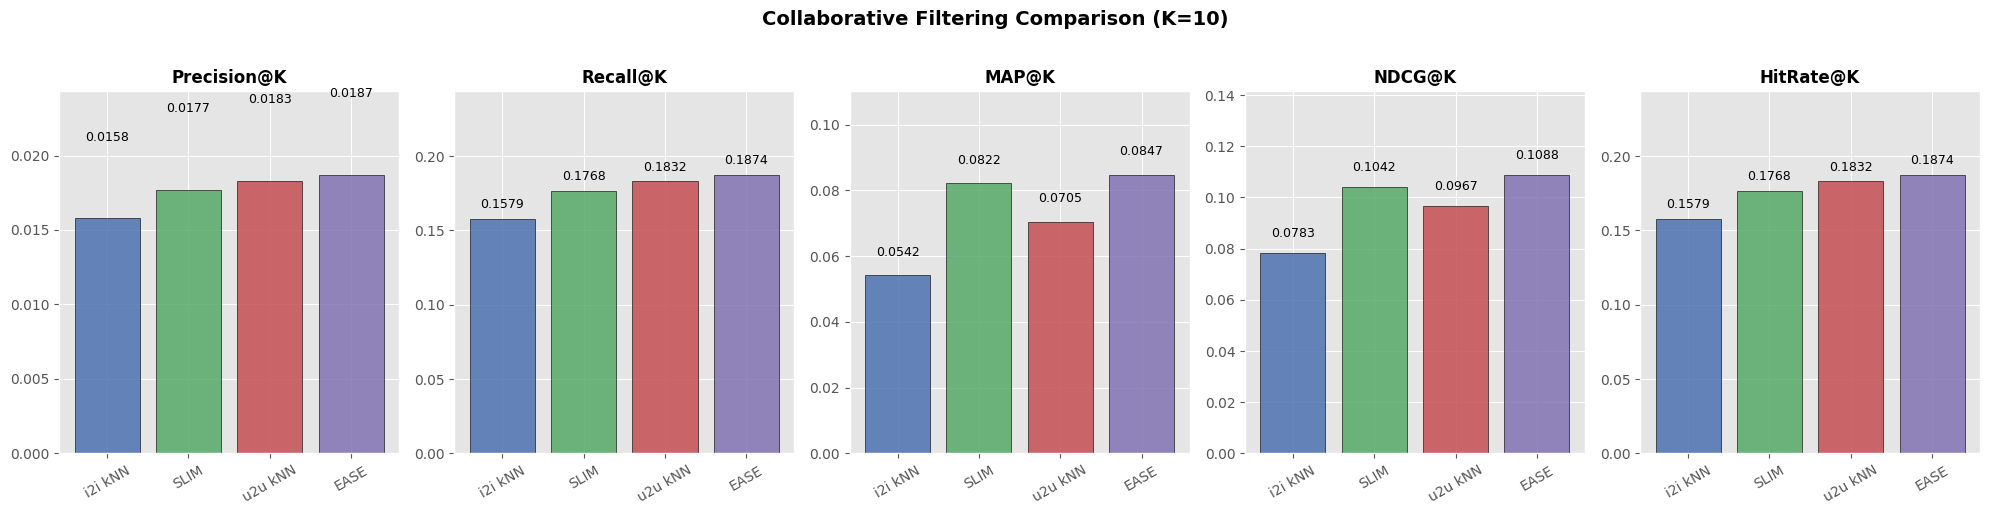

In [56]:
fig, axes = plt.subplots(1, len(results_df.columns), figsize=(4 * len(results_df.columns), 5))

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, metric in zip(axes, results_df.columns):
    values = results_df[metric]
    bars = ax.bar(values.index, values.values, color=colors, edgecolor="black", alpha=0.85)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(0, max(values.values) * 1.3)
    for bar, v in zip(bars, values.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{v:.4f}", ha="center", va="bottom", fontsize=9,
        )
    ax.tick_params(axis="x", rotation=30)

plt.suptitle(f"Collaborative Filtering Comparison (K={K})", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Discussion

**Key takeaways:**

1. **Memory-based methods** (i2i kNN, u2u kNN) are simple and interpretable but
   may struggle with sparse data. i2i is typically more stable than u2u because
   item profiles change less frequently than user profiles.

2. **SLIM** learns a sparse item-item weight matrix through elastic net regression.
   Sparsity acts as feature selection, keeping only the most meaningful item-item
   relationships. The L1 penalty encourages sparsity, while L2 prevents overfitting.

3. **EASE** achieves competitive results with a single closed-form matrix inversion.
   It is computationally efficient at training time (no iterative optimization)
   and has only one hyperparameter ($\lambda$).

4. All four methods operate on the **user-item interaction matrix** without any
   content features. This is both their strength (no cold-start for existing users/items)
   and their limitation (they cannot handle new users or new items).